# Kaggle Clash 2 — Data understanding

## tl;dr
The full reconstruction audit passed 30/30 checks across train and test. The gold corpus contains 766 exact values assigned more than one category across occurrences, warranting context and annotation-noise review. The five-stage audit covers annotation conventions, label context, metadata associations, and observable train/test distributions. Read [REPORT.md](../../note/REPORT.md) for the integrated findings and decisions. This notebook supplies executed tables, figures, and independent reconciliations; audit scripts retain the full calculations and examples.

## Context & Methods
All input is the supplied local competition corpus. Character offsets use Python Unicode characters with an exclusive end. Gold annotations belong to train only; test slots disclose entity counts, not labels. No training or submission is performed here.

### Key Assumptions
- Gold annotations define the target convention; unusual annotations are not automatically mistakes.
- Header/signature regions and identifier formats are explicit heuristics, not ground truth.
- Distribution similarity is descriptive, not a guarantee of generalization. Operational timestamps are synthetic.
- Exact duplicates are checked; no exhaustive near-duplicate semantic search is claimed.

### Reproduction
From the repository root: `uv run src/audit_reconstruction.py`, `uv run src/audit_annotations.py`, `uv run src/audit_metadata.py`, then `uv run src/build_understanding_notebook.py`.
The saved notebook checks SHA-256 hashes before using existing audit results. Change `RUN_AUDITS` below to recompute them in a kernel with the dependencies declared in the builder script. After source changes, rerun the audits and builder to generate a new manifest.


In [1]:
from pathlib import Path
import collections, csv, hashlib, importlib.metadata, json, subprocess, sys
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import pyarrow.parquet as pq
from IPython.display import display, Markdown

ROOT = next(p for p in [Path.cwd(), *Path.cwd().parents] if (p / 'Data/README.txt').exists())
OUT = ROOT / 'output/data_understanding'
RUN_AUDITS = False
if RUN_AUDITS:
    for name in ['audit_reconstruction.py', 'audit_annotations.py', 'audit_metadata.py']:
        result = subprocess.run([sys.executable, str(ROOT / 'src' / name)], cwd=ROOT, capture_output=True, text=True)
        if result.returncode:
            raise RuntimeError(result.stderr[-4000:])
        print(name, 'completed')
manifest = json.loads((OUT / 'manifest.json').read_text())
for entry in manifest['files']:
    # Generated JSON may change when audits rerun (execution timestamp); raw inputs and code must still match.
    if RUN_AUDITS and entry['path'].startswith('output/'):
        continue
    h = hashlib.sha256()
    with (ROOT / entry['path']).open('rb') as stream:
        for chunk in iter(lambda: stream.read(1024 * 1024), b''):
            h.update(chunk)
    assert h.hexdigest() == entry['sha256'], f"Changed input/artifact: {entry['path']}"
recon = json.loads((OUT / 'reconstruction.json').read_text())
ann = json.loads((OUT / 'annotations.json').read_text())
meta = json.loads((OUT / 'metadata.json').read_text())
examples = json.loads((OUT / 'annotations_examples.json').read_text())
plt.rcParams.update({'figure.figsize': (10, 4.5), 'font.size': 11, 'axes.spines.top': False,
                     'axes.spines.right': False, 'axes.titlepad': 14, 'savefig.bbox': 'tight'})
BLUE, GOLD = '#275D8C', '#AA6A13'
print('Input and artifact hashes verified:', len(manifest['files']))
print({p: importlib.metadata.version(p) for p in ['pyarrow','numpy','pandas','scipy','matplotlib']})


Input and artifact hashes verified: 16
{'pyarrow': '25.0.1', 'numpy': '2.5.3', 'pandas': '3.0.5', 'scipy': '1.18.1', 'matplotlib': '3.11.2'}


## Data
Full-scan sources: shuffled segment CSVs, gold label CSV, both metadata Parquets, submission slots, and weak JSONL structural checks. Weak labels are excluded from convention/context analysis. Rows below are file-level provenance, not inferred freshness.

In [2]:
display(pd.DataFrame(recon['sources'])[['path', 'bytes']])
train_meta = pq.read_table(ROOT / 'Data/train/train_metadata.parquet').to_pandas()
test_meta = pq.read_table(ROOT / 'Data/test/test_metadata.parquet').to_pandas()
gold = pd.read_csv(ROOT / 'Data/train/train_labels.csv', keep_default_na=False)
counts = gold.groupby('label').size().sort_values(ascending=False)
assert int(counts.sum()) == ann['denominators']['annotations'] == meta['scope']['train_labels']


,path,bytes
0,Data/extra/weak_labeled_documents.jsonl,38714366
1,Data/README.txt,4370
2,Data/sample_submission.csv,6562331
3,Data/test/test_metadata.parquet,543306
4,Data/test/test_segments.csv,32838408
5,Data/train/train_labels.csv,21869170
6,Data/train/train_metadata.parquet,1584556
7,Data/train/train_segments.csv,98528367


## Results
### 1. Reconstruction verification
The checks use the exact source text without stripping, normalization, or blank-row removal. Hash normalization is used only to detect duplicates, never to replace model input. A structural pass cannot prove that every gold annotation is semantically correct.

In [3]:
checks = pd.DataFrame(recon['checks'])
display(checks[['name','status','failures','denominator']])
display(pd.DataFrame({s: {k: recon['splits'][s][k] for k in ['documents','segments','empty_segments','documents_with_non_ascii']} for s in ['train','test']}).T)
print('Identical training-document groups:', recon['splits']['train']['exact_duplicate_groups'])
print('Duplicate-text annotation conflicts:', recon['duplicate_text_annotation_conflicts'])


,name,status,failures,denominator
0,train: unique metadata document IDs,pass,0,69468
1,train: metadata/segments document join,pass,0,69468
2,train: unique segment indices,pass,0,69468
3,train: contiguous zero-based segment indices,pass,0,69468
4,train: n_chars,pass,0,69468
5,train: n_segments,pass,0,69468
6,train: n_words,pass,0,69468
7,train: n_nonempty_segments,pass,0,69468
8,test: unique metadata document IDs,pass,0,23156
9,test: metadata/segments document join,pass,0,23156


,documents,segments,empty_segments,documents_with_non_ascii
train,69468,1094244,419265,1954
test,23156,364845,139683,673


Identical training-document groups: [['DOC_121192', 'DOC_108124']]
Duplicate-text annotation conflicts: []


### 2. Annotation convention audit
The first chart gives the scoring weight of each category in train. The boundary table distinguishes characters inside a span from characters adjacent to it. Detailed exceptions retain document IDs and exact offsets in `annotations_examples.json`.

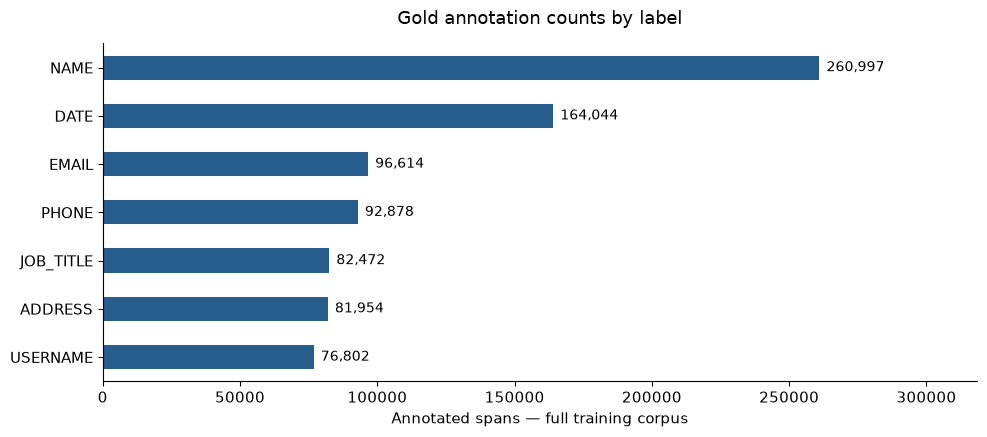

,count,leading_whitespace,trailing_whitespace,internal_newline,leading_punctuation,trailing_punctuation
NAME,260997,8,0,0,1392,3717
EMAIL,96614,1,0,0,798,794
PHONE,92878,3,0,0,64548,631
USERNAME,76802,2,0,0,1436,1480
ADDRESS,81954,1,0,1368,441,443
JOB_TITLE,82472,0,0,0,381,584
DATE,164044,1,0,0,787,796


,count,chars,honorific_included,honorific_excluded,numeric_or_reference_like
NAME,260997.0,3457254.0,44120.0,125056.0,0.0
EMAIL,96614.0,2576493.0,0.0,0.0,0.0
PHONE,92878.0,1225428.0,0.0,0.0,0.0
USERNAME,76802.0,858550.0,0.0,0.0,34899.0
ADDRESS,81954.0,3040259.0,0.0,0.0,0.0
JOB_TITLE,82472.0,1587958.0,0.0,0.0,0.0
DATE,164044.0,2625477.0,0.0,0.0,0.0


,value,labels,total
0,Emily Carter,"{'NAME': 4313, 'JOB_TITLE': 1}",4314
1,Dr. Evelyn Reed,"{'NAME': 2540, 'JOB_TITLE': 7}",2547
2,Mr. David Chen,"{'NAME': 2524, 'JOB_TITLE': 1}",2525
3,Dr. Eleanor Vance,"{'NAME': 2222, 'JOB_TITLE': 18}",2240
4,Dr. Benjamin Carter,"{'NAME': 1940, 'JOB_TITLE': 11}",1951
5,Dr. Anya Sharma,"{'NAME': 1722, 'JOB_TITLE': 15}",1737
6,Mr. Benjamin Carter,"{'NAME': 1665, 'JOB_TITLE': 1}",1666
7,eleanor.vance@example.com,"{'EMAIL': 1496, 'USERNAME': 5}",1501


In [4]:
fig, ax = plt.subplots()
counts.sort_values().plot.barh(ax=ax, color=BLUE)
ax.set(title='Gold annotation counts by label', xlabel='Annotated spans — full training corpus', ylabel='')
for i, value in enumerate(counts.sort_values()):
    ax.text(value + counts.max() * .01, i, f'{value:,}', va='center', fontsize=10)
ax.set_xlim(0, counts.max() * 1.22)
fig.tight_layout(); fig.savefig(OUT / 'label_counts.png'); plt.show()
boundary = pd.DataFrame(ann['boundary_by_label']).T
display(boundary[['count','leading_whitespace','trailing_whitespace','internal_newline','leading_punctuation','trailing_punctuation']])
display(pd.DataFrame(ann['label_profile']).T.fillna(0))
display(pd.DataFrame(ann['cross_label_values_top'][:8]))


### 3. Label-context profiling
Each row below sums to 100% within a gold label. Region assignments are position/text heuristics; `signature_or_tail` must not be read as confirmed signatures. The full report also retains channel/domain counts and frequent neighboring fragments.

,header,body,opening,signature_or_tail,paragraph_boundary
NAME,9.98,39.22,27.51,21.94,1.36
EMAIL,1.12,78.79,0.64,9.90,9.55
PHONE,0.02,81.85,0.11,6.18,11.84
USERNAME,5.70,62.57,7.28,6.93,17.51
ADDRESS,0.33,55.02,12.06,11.22,21.38
JOB_TITLE,3.06,29.88,6.04,58.63,2.39
DATE,7.22,58.03,20.87,4.10,9.78


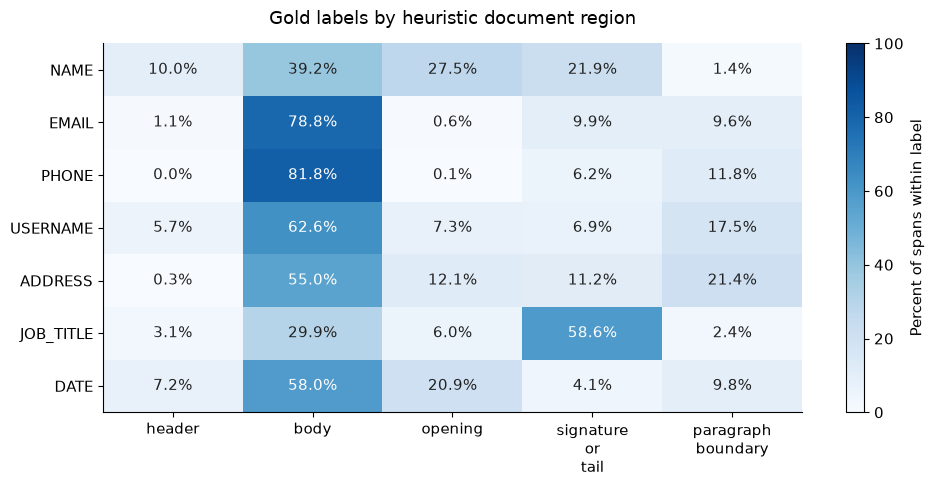

,Observed count
annotated_repeated_values,54990
unlabelled_exact_occurrences,2231
overlapping_unlabelled_occurrences,2231
free_unlabelled_occurrences,0
documents_with_repeated_value,32887
documents_with_unlabelled_repeat,1990


In [5]:
regions = pd.DataFrame(ann['region_by_label']).T.fillna(0)
assert (regions.sum(axis=1).astype(int) == counts.reindex(regions.index)).all()
shares = regions.div(regions.sum(axis=1), axis=0) * 100
display(shares.round(2))
fig, ax = plt.subplots(figsize=(10, 5))
im = ax.imshow(shares.to_numpy(), cmap='Blues', vmin=0, vmax=100, aspect='auto')
ax.set_xticks(range(len(shares.columns)), [c.replace('_', '\n') for c in shares.columns])
ax.set_yticks(range(len(shares)), shares.index)
ax.set_title('Gold labels by heuristic document region')
for i in range(len(shares)):
    for j in range(len(shares.columns)):
        value = shares.iloc[i,j]
        ax.text(j, i, f'{value:.1f}%', ha='center', va='center', color='white' if value > 55 else '#222222')
fig.colorbar(im, ax=ax, label='Percent of spans within label')
fig.tight_layout(); fig.savefig(OUT / 'label_regions.png'); plt.show()
display(pd.Series(ann['repetition'], name='Observed count').to_frame())


### 4. Metadata signal audit
These are associations in the observed training corpus, not held-out predictive utility. Text length/count metadata is a redundant description of the reconstructed string. Operational group means are recomputed below directly from gold counts and metadata to cross-check the audit artifact.

In [6]:
doc_counts = gold.groupby('document_id').size().rename('entity_count')
joined = train_meta.merge(doc_counts, left_on='document_id', right_index=True, how='left', validate='one_to_one')
assert joined['entity_count'].notna().all()
source_summary = joined.groupby('source_system')['entity_count'].agg(['size','mean','std'])
for source, row in source_summary.iterrows():
    expected = meta['operational_associations_train']['source_system'][str(source)]
    assert int(row['size']) == expected['documents']
    assert np.isclose(row['mean'], expected['gold_count_mean'])
display(source_summary.round(4))
correlations = joined[['n_chars','n_segments','n_words','n_nonempty_segments','entity_count']].corr()
display(correlations.round(3))
for label, chunk in meta['categorical_comparison'].items():
    print(label, 'train/test TVD =', round(chunk['total_variation_distance'], 6))


,size,mean,std
source_system,,,
crm-export,11526,12.3552,2.8137
docstore-eu,11515,12.3019,2.7973
docstore-us,11581,12.3256,2.8261
mailgate-01,11527,12.2787,2.7972
mailgate-02,11652,12.3113,2.8044
scan-intake,11667,12.3398,2.8369


,n_chars,n_segments,n_words,n_nonempty_segments,entity_count
n_chars,1.000,0.499,0.968,0.438,0.112
n_segments,0.499,1.000,0.503,0.959,0.130
n_words,0.968,0.503,1.000,0.432,0.089
n_nonempty_segments,0.438,0.959,0.432,1.000,0.235
entity_count,0.112,0.130,0.089,0.235,1.000


channel train/test TVD = 0.006075
domain train/test TVD = 0.007831
source_system train/test TVD = 0.005369


### 5. Train/test distribution comparison
Both splits use the same definitions. Entity count is measured from gold spans in train and exposed slots in test. Small standardized differences and small KS distances support similarity only for the variables actually measured; test entity labels remain unavailable.

,field,train_mean,test_mean,standardized_difference,KS_distance
0,n_chars,1195.51067,1195.22392,-0.00176,0.00530
1,n_segments,15.75177,15.75596,0.00107,0.00252
2,n_words,180.07913,180.04198,-0.00154,0.00458
3,n_nonempty_segments,9.71640,9.72370,0.00290,0.00361


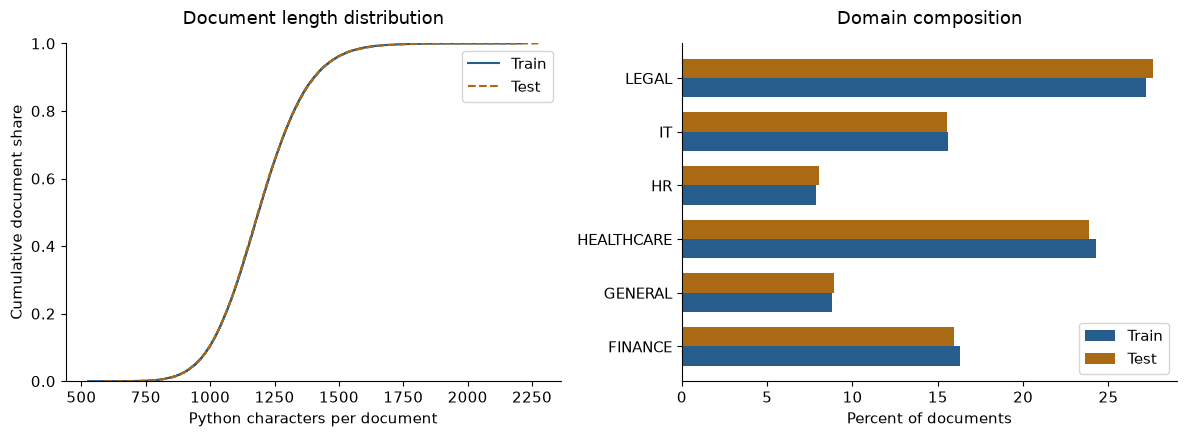

,mean_newlines_per_document,mean_empty_segments_per_document,digit_doc_rate,email_doc_rate
train,14.751771,6.035369,0.997740,0.976982
test,14.755960,6.032259,0.997754,0.977630


,Value
exact_document_hash_overlap,0.000000
whitespace_normalized_overlap,0.000000
case_sensitive_whitespace_token_vocab_overlap,35894.000000
test_token_occurrence_oov_rate_vs_train,0.007446
train_vocab_unique_tokens,135686.000000
test_vocab_unique_tokens,65450.000000


In [7]:
rows = []
for field, item in meta['numeric_comparison'].items():
    rows.append({'field': field, 'train_mean': item['train']['mean'], 'test_mean': item['test']['mean'],
                 'standardized_difference': item['standardized_mean_difference'], 'KS_distance': item.get('ks_statistic')})
display(pd.DataFrame(rows).round(5))
fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))
for label, data, color, linestyle in [('Train',train_meta,BLUE,'-'),('Test',test_meta,GOLD,'--')]:
    values = np.sort(data['n_chars'].to_numpy())
    axes[0].plot(values, np.arange(1, len(values)+1)/len(values), label=label, color=color, linestyle=linestyle)
axes[0].set(title='Document length distribution', xlabel='Python characters per document', ylabel='Cumulative document share', ylim=(0,1))
axes[0].legend()
domains = sorted(set(train_meta.domain) | set(test_meta.domain))
x = np.arange(len(domains))
for label, data, color, offset in [('Train',train_meta,BLUE,-.18),('Test',test_meta,GOLD,.18)]:
    values = data.domain.value_counts(normalize=True).reindex(domains, fill_value=0) * 100
    axes[1].barh(x + offset, values, .36, label=label, color=color)
axes[1].set_yticks(x, domains)
axes[1].set(title='Domain composition', xlabel='Percent of documents', ylabel='')
axes[1].legend()
fig.tight_layout(); fig.savefig(OUT / 'train_test_comparison.png'); plt.show()
display(pd.DataFrame(meta['formatting']).T)
display(pd.Series(meta['text_overlap'], name='Value').to_frame())


## Takeaways
Use the integrated [report](../../note/REPORT.md) to distinguish verified findings, ambiguous conventions, and next tests. Preserve raw strings; group identical documents during validation; inspect labels in context before writing normalization rules. Use metadata to describe and stratify evaluation before claiming feature value. Test distribution similarity does not establish hidden-label similarity.

The weak-data scan establishes structural validity only; it does not measure semantic precision or recall. The sample submission contains placeholders, not labels. This notebook does not change the baseline, train a model, or submit predictions.
